# 07b · The same campaign question, on real data — Google's geo experiment ⭐ (companion)

**The business decision.** A real advertiser spent **$50,000** on a real ad campaign, in **50 US
geos, for four weeks** (16 Feb – 15 Mar 2015), and left 50 geos dark. This is the worked example
published with Google's geo-experiment methodology (Kerman, Wang & Vaver 2017, the
`matched_markets` library) — daily **sales and ad cost per geo**, exactly the panel your own
company's data warehouse holds. The question is the one notebook [07](07_geo_lift_synthetic_control.ipynb)
trained us for: **how much incremental sales did the spend cause, and did it pay for itself?**

### What changes when the data is real

Notebook 07 planted a +12% lift in a simulator and graded synthetic control against it. Here nobody
tells us the truth — that is the whole epistemic situation of applied causal inference. Three things
replace the planted truth:

1. **A randomized benchmark.** The 100 geos were split into treatment and control **at random**
   (in matched pairs, as we'll verify from the data itself). So a design-based estimate — the
   matched-pairs difference-in-differences — is *unbiased by construction*. (Recall 07's
   difference-in-differences: the *change* in the treated group, post minus pre, minus the same
   change in the control group; randomizing which geos are treated makes that difference unbiased
   for the campaign effect, because the two groups can then differ only by the coin flip.) It is
   noisy, but it is
   the closest real data ever gets to a known answer, and we grade the synthetic control against it.
2. **Falsification tests** that need no truth: placebo campaigns on untreated geos (Depth B), a
   fake launch date, and a check the simulator could never give us for free — the campaign *ends*,
   so the estimated effect must **switch off when the money does**.
3. **Real messiness**: missing geo-days, heavy-tailed market sizes (the largest geo sells 300× the
   smallest), and a weekly cycle you can see with the naked eye. Each one bites somewhere below,
   and one of them (market size) breaks a naive estimator in Depth A.

### How this notebook is organised

The same **7-step contract** as every notebook — with step 2's "simulate a ground truth" honestly
replaced by "load real data, and say what can still be validated" — plus the anchor depths:

- **Depth A** — the naive estimators on a *single* real market (where they fail for real), and a
  convex-hull failure the pre-fit gate catches
- **Depth B** — placebo inference: pseudo-cell permutation, the scale-free RMSE-ratio, placebo-in-time
- **Depth C** — the dollar decision and its sensitivity to the launch date, the donor pool, and the margin


In [1]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from cmp import data, estimators as est, policy, plots
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 1
SPEND = 50.0     # the experiment's actual ad spend, $000s (from the cost column)
MARGIN = 0.35    # assumed gross margin for the profit call — swept in Depth C
SC = dict(draws=600, tune=600, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
N_PSEUDO = 60 if FAST else 200
print(f"FAST={FAST}  SC sampling={SC}  pseudo-cells={N_PSEUDO}")

FAST=False  SC sampling={'draws': 1500, 'tune': 1500, 'chains': 4}  pseudo-cells=200


## 2 · Load the real data (what replaces "simulate a ground truth")

`cmp.data.load_google_geo()` fetches the two public CSVs (Apache-2.0, pinned commit; ~230 KB —
cached under `~/.cache/cmp` after the first call) and returns the long panel: `date, geo, sales,
cost, group`. The **data card**, verified in code below:

| fact | value |
|---|---|
| units | 100 US geos, **numbered by size** (geo 1 = largest — visible in the data) |
| period | 93 days, 2015-01-05 → 2015-04-07, daily |
| design | randomized in **matched pairs**: consecutive size-ranked geos split 1 treated / 1 control |
| treatment | ad campaign in the 50 group-2 geos, 16 Feb – 15 Mar (28 days), **$50,000** total spend |
| cooldown | 23 days *after* the spend stops — a free falsification window |
| blemishes | 75 of 9,300 geo-days missing at source (small geos, mostly pre-period) — we interpolate and disclose |

Two working conventions. **(a)** We analyse sales in **$000s** — same numerical scale the fitters
were built for. **(b)** The treated unit is the **test cell**: the *mean* daily sales per treated
geo. The mean (not the sum) keeps the treated series inside the donors' range — a sum of 50 geos
could never be a convex combination of single geos (the synthetic counterfactual is only ever a
weighted average of the donor geos, so it can never rise above the biggest donor or fall below the
smallest — the treated series must sit *inside* the donors' range, their 'convex hull'), and Depth A shows what happens when a series
escapes the donor hull.

Eyeball the panel below before any model: every geo rides the same weekly cycle (the shared
factors of 07, no longer a modelling assumption but a visible fact), and the treated cell visibly
jumps *inside the campaign window only*.

100 geos (50 treated / 50 control) · 93 days · campaign days 42–69 (28 days) · cooldown 23 days
interpolated geo-days: 75/9300 (0.8%) — small geos, mostly pre-period
ad spend: $0 before launch (no anticipation), $50,000 inside the window, $0 after — the design is clean
geo sizes are heavy-tailed: largest $6,728/day vs smallest $18/day (~369x)


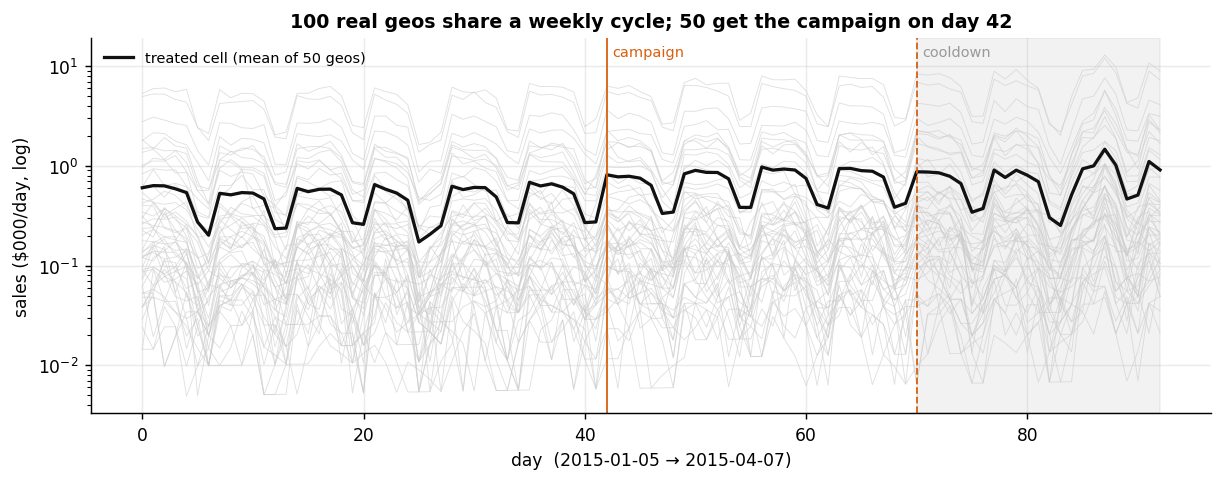

In [2]:
geo_df = data.load_google_geo()                       # date, geo, sales ($), cost ($), group
raw_panel = geo_df.pivot(index="date", columns="geo", values="sales")
n_missing = int(raw_panel.isna().sum().sum())
panel = raw_panel.interpolate(limit_direction="both") / 1000.0        # $000s per geo per day
cost = geo_df.pivot(index="date", columns="geo", values="cost").fillna(0.0)
group = geo_df.drop_duplicates("geo").set_index("geo")["group"]
treated_geos = [g for g in panel.columns if group[g] == 2]
control_geos = [g for g in panel.columns if group[g] == 1]
dates = panel.index
launch = int((dates < "2015-02-16").sum())            # first day with ad spend
end_post = int((dates <= "2015-03-15").sum())         # day after the last campaign day
W = len(dates)
pre, post, cool = slice(0, launch), slice(launch, end_post), slice(end_post, W)
n_treat, n_days = len(treated_geos), end_post - launch
t = np.arange(W)

y_tr = panel[treated_geos].mean(axis=1).values        # the treated CELL (mean $000s/geo/day)
donors = panel[control_geos].values.T                 # (50, W) donor pool

fig, ax = plt.subplots(figsize=(9.5, 3.8))
for g in control_geos:
    ax.plot(t, panel[g], color="#cccccc", lw=0.5, alpha=0.6)
ax.plot(t, y_tr, color="#111", lw=1.8, label="treated cell (mean of 50 geos)")
ax.axvline(launch, color=plots.ORANGE, lw=1); ax.axvline(end_post, color=plots.ORANGE, lw=1, ls="--")
ax.axvspan(end_post, W - 1, color=plots.GREY, alpha=0.12)
ax.text(launch + 0.5, ax.get_ylim()[1] * 0.92, "campaign", color=plots.ORANGE, fontsize=8)
ax.text(end_post + 0.5, ax.get_ylim()[1] * 0.92, "cooldown", color=plots.GREY, fontsize=8)
ax.set_yscale("log")                                   # heavy-tailed geo sizes: log to see everyone
ax.set_xlabel(f"day  ({dates[0].date()} → {dates[-1].date()})"); ax.set_ylabel("sales ($000/day, log)")
ax.set_title("100 real geos share a weekly cycle; 50 get the campaign on day 42")
ax.legend(frameon=False, fontsize=8); fig.tight_layout()

pre_spend = float(cost.values[:launch].sum()); win_spend = float(cost.values[launch:end_post].sum())
print(f"{len(panel.columns)} geos ({n_treat} treated / {len(control_geos)} control) · {W} days · "
      f"campaign days {launch}–{end_post - 1} ({n_days} days) · cooldown {W - end_post} days")
print(f"interpolated geo-days: {n_missing}/{panel.size} ({n_missing / panel.size:.1%}) — small geos, mostly pre-period")
print(f"ad spend: ${pre_spend:.0f} before launch (no anticipation), ${win_spend:,.0f} inside the window, "
      f"${float(cost.values[end_post:].sum()):.0f} after — the design is clean")
print(f"geo sizes are heavy-tailed: largest ${panel.mean().max() * 1000:,.0f}/day vs smallest "
      f"${panel.mean().min() * 1000:,.0f}/day (~{panel.mean().max() / panel.mean().min():.0f}x)")

## 3 · Identify — the estimand, and what randomization buys us

**The estimand.** Total incremental sales caused by the campaign in the treated geos over the
28-day window:

$$\tau \;=\; \sum_{t=T_0}^{T_1} \Big( Y_{\text{cell},t}(1) - Y_{\text{cell},t}(0) \Big) \times 50,$$

where $Y_{\text{cell},t}$ is mean sales per treated geo and the $\times 50$ restores cell totals.
Recall 07's potential-outcome notation: $Y_{\text{cell},t}(1)$ is sales *with* the campaign (what
we observe in the treated geos) and $Y_{\text{cell},t}(0)$ is what those same geos *would* have
sold with no campaign — the never-observed counterfactual the synthetic control must reconstruct.
The estimator is exactly 07's: simplex-weighted donors fit to the pre-period fill in the missing
$Y_{\text{cell},t}(0)$ (see [07 §3](07_geo_lift_synthetic_control.ipynb) for the full math and the
convex-hull argument). The dollar decision then divides by spend: **iROAS** $= \tau / \$50\text{k}$,
incremental revenue per ad dollar.

**The assumptions, upgraded by the design.** In 07 most rows of this table were unverifiable
promises; here randomization converts the worst one into a guarantee:

| assumption | status on this real dataset |
|---|---|
| **convex hull / no extrapolation** | *checked*: the treated cell (a mean of 50 geos) sits mid-range of the donors; Depth A shows geo 1 violating it and the gate catching it |
| **good pre-fit** | *checked*: 42 pre-days, PASS/FAIL gate in Step 5 |
| **no anticipation** | *checked from data*: $0 of spend before day 42 |
| **stable co-movement** | *supported*: shared weekly cycle visible; placebo-in-time (Depth B) probes it |
| **no spillover between geos** | *assumed*: geos are distinct media markets, but adjacency isn't in the data — the honest caveat that survives even randomization |
| **no concurrent treated-only shock** | **guaranteed in expectation by randomization** — a shock would have to coincide with a random coin flip across 50 pairs; in 07 this row was "institutional knowledge only" |

**Why bother with synthetic control if the design is randomized?** Because the design-based
estimate, while unbiased, is *noisy* — geo sizes are so heavy-tailed that a plain
treatment-vs-control comparison has a wide interval (Step 5 quantifies this). Synthetic control
re-weights donors to *match* the treated cell and cuts that variance. And the moment you leave
experiments — one treated market, chosen not by coin flip — SC is the only member of this family
still standing. That is the real lecture point of this notebook: **the experiment validates the
method we'll use when there is no experiment.**

## 4 · Estimate — Bayesian synthetic control on the test cell

Same model as 07: **Dirichlet-simplex weights** over the 50 control geos, fit to the 42 pre-launch
days, returning a posterior over the counterfactual path — and therefore over total lift and iROAS.
Read three things off the fit, exactly as in 07: **which donors** carry weight (the Dirichlet
spreads it — expect a high "effective number of donors" on a mean-of-50 target), the **pre-fit
RMSE** (Step 5 turns it into a PASS/FAIL gate), and the **counterfactual band** (a posterior
predictive, carrying the cell's own daily noise, not just weight uncertainty).

**And read the convergence line — including the divergences.** The sampler already runs at
`target_accept = 0.95`, yet NUTS still reports some divergent transitions (the exact count, r-hat,
and ESS are printed below). The geometry is the suspect: 50 simplex weights pressed against a noise
scale of ~2% of the level create funnel-like corners the integrator occasionally overshoots. We do
*not* wave this away — divergences are the one warning that can invalidate a fit even when r-hat
looks perfect. Two checks argue these are benign: the r-hat/ESS readout below says the chains agree on the
same posterior (**r-hat** near 1.0 means the independent chains landed on the same distribution; **ESS** — effective sample size — is the number of *effectively independent* draws behind each estimate, and the several thousand (~3,300) printed below is healthy), and — decisive — Step 5 refits the *same* objective with a divergence-free SLSQP optimizer (SLSQP is a plain numerical optimizer that finds the single best simplex weights directly, with no sampling and therefore no divergences, so it solves the *same* fit as a clean cross-check on the Bayesian total) and prints how far the two totals sit apart (a small fraction of the posterior's own 90%
width). If that cross-check disagreed, the right move would be reparameterization, not narration.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [w, sd]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 31 seconds.


There were 56 divergences after tuning. Increase `target_accept` or reparameterize.


SC sampling convergence: max r-hat 1.000 - min ESS 3268 - divergences 56
pre-fit RMSE $10/geo/day on a ~$472 level (~2%)
total incremental sales $149k  90% CI [$141k, $158k]  on $50k of spend
revenue iROAS 2.98  90% CI [2.81, 3.15]


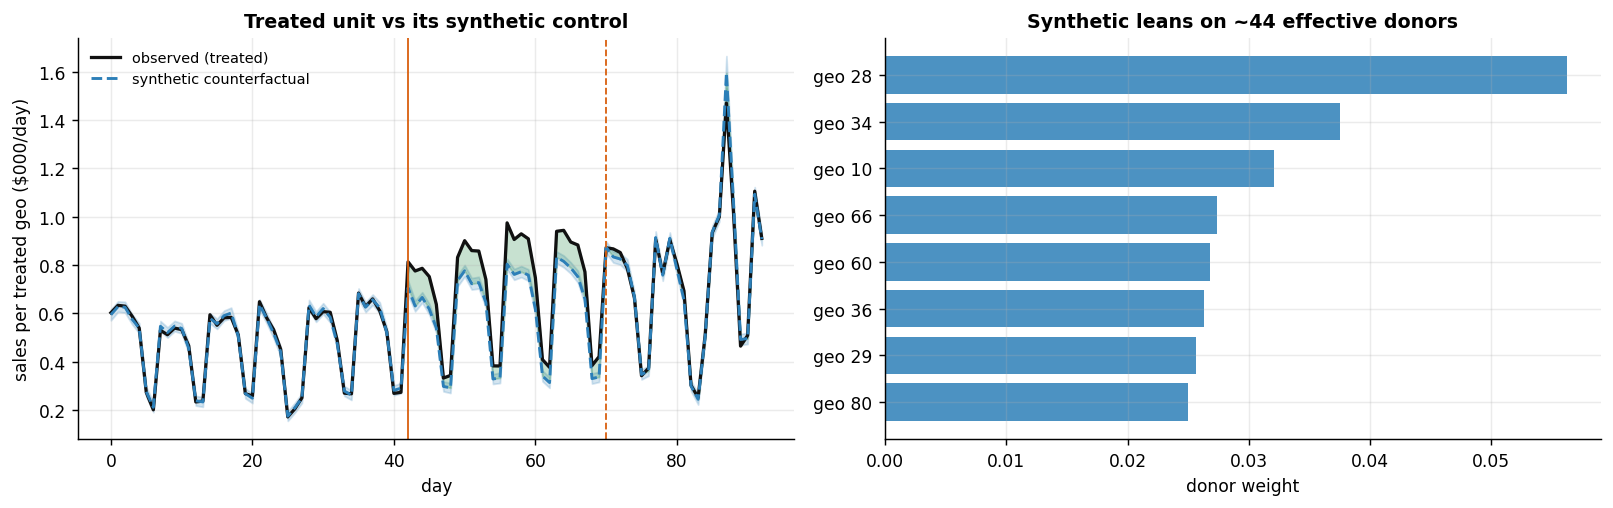

In [3]:
sc = est.synthetic_control(y_tr, donors, pre, post, seed=SEED, **SC)
print(f"SC sampling convergence: {sc['convergence']['summary']}")
cf = sc["counterfactual_samples"]; effect = sc["effect_samples"]
total_post = effect[:, post].sum(1) * n_treat          # $000s of incremental sales, cell total
iroas = total_post / SPEND
w_mean = sc["weight_samples"].mean(0)
eff_n = 1.0 / np.sum(w_mean ** 2)
topw = np.argsort(-w_mean)[:8]

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
plots.sc_counterfactual_plot(ax[0], t, y_tr, cf, launch, xlabel="day",
                             ylabel="sales per treated geo ($000/day)")
ax[0].axvline(end_post, color=plots.ORANGE, lw=1, ls="--")
ax[1].barh([f"geo {control_geos[i]}" for i in topw][::-1], w_mean[topw][::-1],
           color=plots.BLUE, alpha=0.85)
ax[1].set_xlabel("donor weight"); ax[1].set_title(f"Synthetic leans on ~{eff_n:.0f} effective donors")
fig.tight_layout()

lo, hi = np.quantile(total_post, [0.05, 0.95]); lo_r, hi_r = np.quantile(iroas, [0.05, 0.95])
print(f"pre-fit RMSE ${sc['pre_rmse'] * 1000:.0f}/geo/day on a ~${y_tr[pre].mean() * 1000:.0f} level (~2%)")
print(f"total incremental sales ${total_post.mean():.0f}k  90% CI [${lo:.0f}k, ${hi:.0f}k]  on ${SPEND:.0f}k of spend")
print(f"revenue iROAS {iroas.mean():.2f}  90% CI [{lo_r:.2f}, {hi_r:.2f}]")

## 5 · Validate — against the randomized experiment

Four checks. The first is the one no simulator can fake: an *unbiased, design-based* estimate of
the same estimand, from the experiment's own randomization.

1. **The matched-pairs DiD anchor.** The assignment pattern in the data shows consecutive
   size-ranked geos were randomized one-treated-one-control (a matched-pairs design — we verify
   this in code). So the mean of the 50 within-pair difference-in-differences is unbiased for the
   campaign effect, with an honest standard error from the pair scatter. Concretely, with
   $\bar Y$ the within-window daily means for the treated/control geo of pair $p$:

   $$d_p \;=\; \big(\bar Y^{\,\text{tr}}_{p,\text{post}} - \bar Y^{\,\text{tr}}_{p,\text{pre}}\big)
        - \big(\bar Y^{\,\text{ct}}_{p,\text{post}} - \bar Y^{\,\text{ct}}_{p,\text{pre}}\big),
   \qquad
   \hat\tau_{\text{DiD}} \;=\; \underbrace{50 \times 28}_{\text{geos}\,\times\,\text{days}}
        \;\cdot\; \frac{1}{50}\sum_{p=1}^{50} d_p,
   \qquad
   \widehat{\mathrm{SE}}\big(\hat\tau_{\text{DiD}}\big) \;=\; 50 \times 28 \cdot \frac{s_d}{\sqrt{50}},$$

   where $s_d$ is the sample standard deviation of the 50 pair differences — exactly the code's
   `pair_diffs` / `did_total` / `did_se`. *Why pairing cuts variance:* each $d_p$ compares a geo to
   its size-matched neighbour, so the size factor differences out *within* every pair; with the
   heavy right tail of geo sizes (the largest sells ~370× the smallest, Step 2), that tail inflates
   $s_d$ far less than it would inflate the spread of a plain two-group DiD. The anchor is our
   stand-in for 07's planted truth: **the synthetic control point should land inside its interval.**
   Note how *wide* that interval still is — unbiasedness isn't precision; this is exactly the
   variance the model is there to cut.
2. **Pre-fit gate** — same concrete rule as 07: pre-RMSE below a third of the daily lift the
   design must detect, printed PASS/FAIL.
3. **The off-switch falsification.** The spend stops on day 70; a real advertising effect should
   collapse toward zero in the 23-day cooldown (up to carryover). A gap that *persists* after the
   money stops would smell of a confound rather than a campaign. This replaces the simulator's
   "we know the truth after week 40" with a physical prediction the data can refute.
4. **Leave-one-out donors** — drop each top-weighted donor, refit (fast SLSQP), watch stability.

**What we cannot do on real data** — and say so plainly, as 07's multi-seed check taught us: we
cannot refit on fresh copies of the world, so we cannot *measure* interval calibration here. 07
found SC's total-lift band runs **optimistic** even when the point is right; carry that lesson —
trust the placebo permutation (Depth B) for significance, not the band width alone.

anchor: matched-pairs DiD total $147k ± 42 (90% CI [78, 216]k; iROAS 2.94 [1.56, 4.32])
        SC total $149k (iROAS 2.98) — lands on the anchor's point with a ~8x tighter band (the variance reduction SC is for; mind 07's optimism lesson on band width)
pre-fit gate: pre-RMSE $10 vs |daily lift|/3 = $36  ->  PASS
off-switch: campaign-window gap $+107/geo/day  ->  cooldown $-3/geo/day (collapses when the spend stops — and no long carryover to book as extra value)
leave-one-out: total ranges $145–150k vs SLSQP baseline $147k — no single donor drives it
divergence cross-check: 56 divergent transitions, but the divergence-free SLSQP refit of the same objective lands $2.5k from the Bayesian total (15% of the 90%-CI width) -> benign (simplex funnel corners, not bias)
interpolation check (a): dropping the 10 gappy donors (near-uniform Dirichlet weight 19%) moves the daily lift $+105 -> $+105/geo/day (0.2% shift) -> interpolation is immaterial
interpolation check (b): dropping all 17 gappy geo

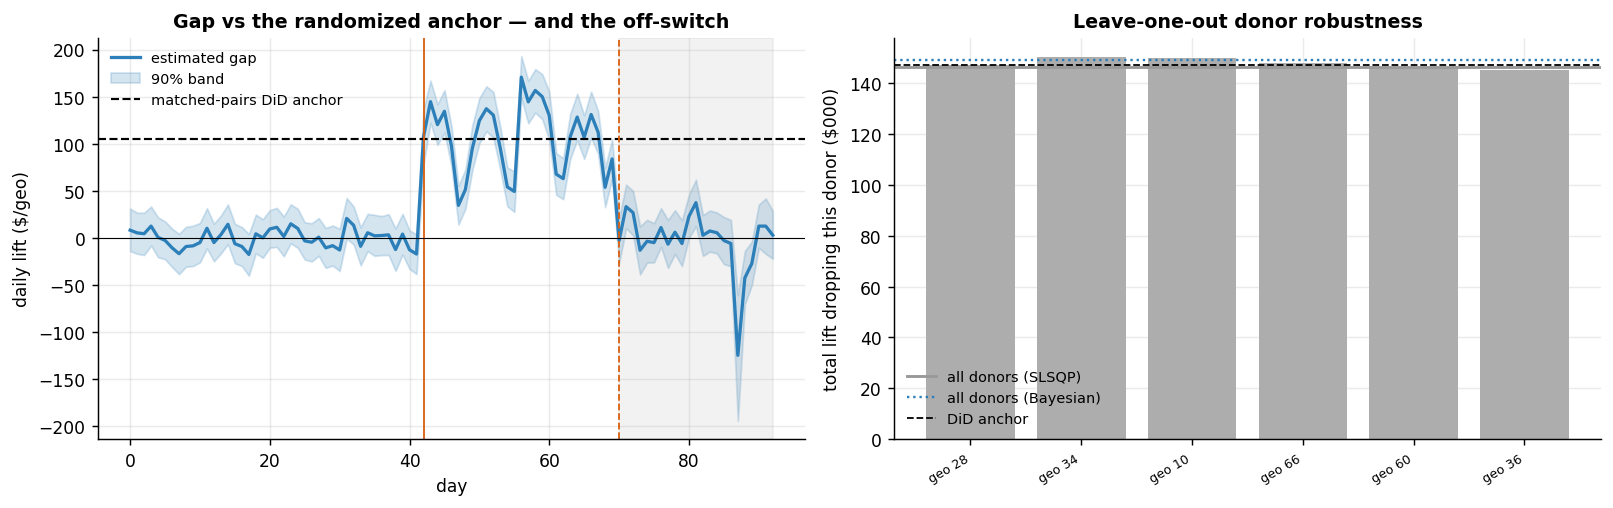

In [4]:
# 1) matched-pairs DiD anchor — pairs are consecutive size-ranked geos, verified 1 treated + 1 control
pairs = [(a, a + 1) for a in range(1, 100, 2)]
assert all({int(group[a]), int(group[b])} == {1, 2} for a, b in pairs), "not a matched-pairs design"
pair_diffs = np.array([
    (panel[tr].values[post].mean() - panel[tr].values[pre].mean())
    - (panel[ctl].values[post].mean() - panel[ctl].values[pre].mean())
    for a, b in pairs for tr, ctl in [((a, b) if group[a] == 2 else (b, a))]])
did_total = pair_diffs.mean() * n_treat * n_days
did_se = pair_diffs.std(ddof=1) / np.sqrt(len(pairs)) * n_treat * n_days

# 2) pre-fit gate (non-oracle: uses the estimated daily lift)
daily_lift = total_post.mean() / n_treat / n_days
gate_ref = abs(daily_lift) / 3
gate = "PASS" if sc["pre_rmse"] < gate_ref else "FAIL"

# 3) off-switch: mean gap in the cooldown vs in the campaign window
eff_mean = effect.mean(0); eff_lo, eff_hi = np.quantile(effect, [0.05, 0.95], 0)
cool_gap, post_gap = eff_mean[cool].mean(), eff_mean[post].mean()

# 4) leave-one-out (fast SLSQP, same-fitter baseline as 07)
slsqp_gap, _ = est.sc_effect_slsqp(y_tr, donors, pre, post)
slsqp_total = slsqp_gap[post].sum() * n_treat
loo = []
for i in topw[:6]:
    keep = [k for k in range(len(control_geos)) if k != i]
    gp, _ = est.sc_effect_slsqp(y_tr, donors[keep], pre, post)
    loo.append(gp[post].sum() * n_treat)

# 5) interpolation robustness (supports the §7 caveat), two reruns (cheap SLSQP):
#    (a) drop the gappy DONORS only — same estimand, tests whether interpolated donor
#        values feed the counterfactual;
#    (b) drop gappy geos on BOTH sides — the cell becomes a mean of the surviving
#        (larger) geos, so its per-geo lift must be graded against the matched-pairs
#        anchor restricted to the same pairs, not against the full cell.
gappy = set(raw_panel.columns[raw_panel.isna().any()])
gappy_w = float(w_mean[[i for i, g in enumerate(control_geos) if g in gappy]].sum())
keep_ng = [i for i, g in enumerate(control_geos) if g not in gappy]
gap_dnr, _ = est.sc_effect_slsqp(y_tr, donors[keep_ng], pre, post)
tr_ng = [g for g in treated_geos if g not in gappy]
y_ng = panel[tr_ng].mean(axis=1).values
gap_ng, _ = est.sc_effect_slsqp(y_ng, donors[keep_ng], pre, post)
anchor_ng = pair_diffs[[i for i, (a, b) in enumerate(pairs)
                        if (a if group[a] == 2 else b) in tr_ng]].mean()

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
ax[0].plot(t, eff_mean * 1000, color=plots.BLUE, lw=1.8, label="estimated gap")
ax[0].fill_between(t, eff_lo * 1000, eff_hi * 1000, color=plots.BLUE, alpha=0.2, label="90% band")
ax[0].axhline(pair_diffs.mean() * 1000, color="k", ls="--", lw=1.2, label="matched-pairs DiD anchor")
ax[0].axvline(launch, color=plots.ORANGE, lw=1); ax[0].axvline(end_post, color=plots.ORANGE, lw=1, ls="--")
ax[0].axvspan(end_post, W - 1, color=plots.GREY, alpha=0.12); ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_xlabel("day"); ax[0].set_ylabel("daily lift ($/geo)")
ax[0].set_title("Gap vs the randomized anchor — and the off-switch")
ax[0].legend(frameon=False, fontsize=8)
ax[1].axhline(slsqp_total, color=plots.GREY, lw=1.6, label="all donors (SLSQP)")
ax[1].axhline(total_post.mean(), color=plots.BLUE, ls=":", lw=1.3, label="all donors (Bayesian)")
ax[1].axhline(did_total, color="k", ls="--", lw=1, label="DiD anchor")
ax[1].bar(range(len(loo)), loo, color=plots.GREY, alpha=0.8)
ax[1].set_xticks(range(len(loo)))
ax[1].set_xticklabels([f"geo {control_geos[i]}" for i in topw[:6]], rotation=30, ha="right", fontsize=7)
ax[1].set_ylabel("total lift dropping this donor ($000)"); ax[1].set_title("Leave-one-out donor robustness")
ax[1].legend(frameon=False, fontsize=8); fig.tight_layout()

print(f"anchor: matched-pairs DiD total ${did_total:.0f}k ± {did_se:.0f} "
      f"(90% CI [{did_total - 1.645 * did_se:.0f}, {did_total + 1.645 * did_se:.0f}]k; iROAS "
      f"{did_total / SPEND:.2f} [{(did_total - 1.645 * did_se) / SPEND:.2f}, {(did_total + 1.645 * did_se) / SPEND:.2f}])")
print(f"        SC total ${total_post.mean():.0f}k (iROAS {iroas.mean():.2f}) — lands on the anchor's point "
      f"with a ~{(1.645 * did_se) / ((hi - lo) / 2):.0f}x tighter band (the variance reduction SC is for; mind 07's optimism lesson on band width)")
print(f"pre-fit gate: pre-RMSE ${sc['pre_rmse'] * 1000:.0f} vs |daily lift|/3 = ${gate_ref * 1000:.0f}  ->  {gate}")
print(f"off-switch: campaign-window gap ${post_gap * 1000:+.0f}/geo/day  ->  cooldown ${cool_gap * 1000:+.0f}/geo/day "
      f"(collapses when the spend stops — and no long carryover to book as extra value)")
print(f"leave-one-out: total ranges ${min(loo):.0f}–{max(loo):.0f}k vs SLSQP baseline ${slsqp_total:.0f}k — "
      f"no single donor drives it")
print(f"divergence cross-check: {sc['convergence']['n_divergences']} divergent transitions, but the "
      f"divergence-free SLSQP refit of the same objective lands ${abs(total_post.mean() - slsqp_total):.1f}k "
      f"from the Bayesian total ({abs(total_post.mean() - slsqp_total) / (hi - lo):.0%} of the 90%-CI width) "
      f"-> benign (simplex funnel corners, not bias)")
print(f"interpolation check (a): dropping the {len(control_geos) - len(keep_ng)} gappy donors "
      f"(near-uniform Dirichlet weight {gappy_w:.0%}) moves the daily lift "
      f"${slsqp_gap[post].mean() * 1000:+.0f} -> ${gap_dnr[post].mean() * 1000:+.0f}/geo/day "
      f"({abs(gap_dnr[post].mean() / slsqp_gap[post].mean() - 1):.1%} shift) -> interpolation is immaterial")
print(f"interpolation check (b): dropping all {len(gappy)} gappy geos on both sides gives "
      f"${gap_ng[post].mean() * 1000:+.0f}/geo/day for the surviving {len(tr_ng)}-geo cell — pure composition "
      f"(bigger geos, bigger per-geo lift), matched by the anchor on the same pairs "
      f"(${anchor_ng * 1000:+.0f}); relative lift {slsqp_gap[post].mean() / y_tr[pre].mean():.1%} vs "
      f"{gap_ng[post].mean() / y_ng[pre].mean():.1%} — unchanged")

**Read-out.** The synthetic control lands almost exactly on the randomized answer —
**$149k vs the anchor's $147k** (iROAS 2.98 vs 2.94) — passing the only exam real data can set. And
the comparison teaches why the model exists at all: the *unbiased* anchor carries a ±$70k-wide 90%
interval (heavy-tailed geo sizes make even 50 randomized pairs noisy), while SC's band is ~8×
tighter around the same point. The gap path shows a clean rectangle: nothing before day 42, a
sustained ~$105/geo/day lift during the four paid weeks, and a collapse to ≈ −$3/geo/day within the
cooldown — the effect **switches off when the money does**, which simultaneously validates the
attribution and tells the media planner there is no adstock annuity to book. Leave-one-out totals
move by ~$3k on a $147k estimate: no single market carries the result.

## 6 · Decide, in dollars

The trap in every iROAS deck: **3.0 revenue-iROAS is not "3× return".** Ad spend buys *revenue*;
the firm keeps only the **gross margin** on it. The campaign pays if

$$\text{iROAS} \times \text{margin} > 1 \qquad\Longleftrightarrow\qquad \text{iROAS} > \tfrac{1}{\text{margin}},$$

so at our assumed 35% margin the bar is not 1.0 but **2.86** — and our posterior sits almost on top
of it. That is the honest shape of this decision: the *lift* is beyond doubt (Depth B), the
*profitability* is a knife-edge that turns entirely on a finance input the model cannot see. The
right briefing separates the two.

{
  "P_value_gt_cost": 0.889,
  "expected_value": 52.189,
  "expected_net_value": 2.189,
  "expected_roi": 0.044,
  "value_lo": 49.251,
  "value_hi": 55.165,
  "cost": 50.0,
  "decision": "TEST FURTHER"
}
break-even margin = 1/iROAS = 33.5%; the campaign clears P(profitable) >= 0.90 only for margins >= 35.5%


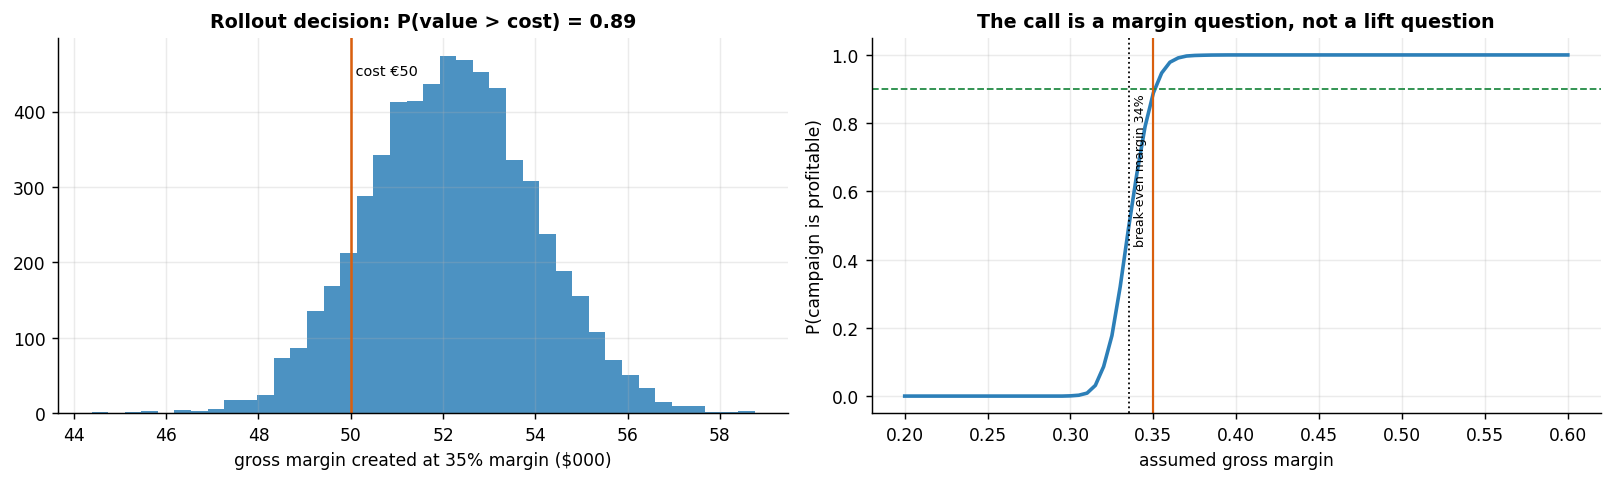

In [5]:
margin_value = total_post * MARGIN                     # $000s of gross margin created
decision = policy.go_no_go(margin_value, SPEND)
margins = np.linspace(0.20, 0.60, 81)
p_pays = np.array([(iroas > 1 / m).mean() for m in margins])
m_be = 1 / iroas.mean()                                # margin where the mean estimate breaks even
m_90 = margins[np.argmax(p_pays >= 0.9)] if (p_pays >= 0.9).any() else np.nan

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
plots.decision_hist(ax[0], margin_value, SPEND)
ax[0].set_xlabel(f"gross margin created at {MARGIN:.0%} margin ($000)")
ax[1].plot(margins, p_pays, color=plots.BLUE, lw=2)
ax[1].axhline(0.9, color=plots.GREEN, ls="--", lw=1); ax[1].axvline(MARGIN, color=plots.ORANGE, lw=1.2)
ax[1].axvline(m_be, color="k", ls=":", lw=1)
ax[1].text(m_be + 0.003, 0.45, f"break-even margin {m_be:.0%}", rotation=90, fontsize=7)
ax[1].set_xlabel("assumed gross margin"); ax[1].set_ylabel("P(campaign is profitable)")
ax[1].set_title("The call is a margin question, not a lift question")
fig.tight_layout()

print(json.dumps({k: (round(v, 3) if isinstance(v, float) else v) for k, v in decision.items()}, indent=2))
print(f"break-even margin = 1/iROAS = {m_be:.1%}; the campaign clears P(profitable) >= 0.90 "
      f"only for margins >= {m_90:.1%}" if np.isfinite(m_90) else
      f"break-even margin = 1/iROAS = {m_be:.1%}; P(profitable) never reaches 0.90 on this margin grid")

## 7 · Caveats

- **The estimate travels; the decision might not.** iROAS ≈ 3 is for *this* creative, *this*
  spend level, *these* 50 geos, in Feb–Mar. A national rollout extrapolates on all four axes —
  diminishing returns alone (nb06's saturation curves) argue the marginal iROAS at 10× spend is lower.
- **Profitability hinges on an input outside the data.** The margin sweep is the honest deliverable;
  a single "GO" at 35% margin overstates what the sales panel can know.
- **Spillover is the surviving assumption.** Randomization can't stop Denver's ads reaching
  Boulder's shoppers; if spend leaks into control geos, both the anchor and SC are biased *downward*
  (control geos absorb some lift), making our estimate mildly conservative.
- **Interval optimism.** 07's multi-seed check showed SC's total-lift band under-covers even when
  the point is right. The agreement with the anchor's *point* is earned; the band's exact width is not.
- **75 interpolated geo-days** (0.8%, small geos, mostly pre-period) — not asserted away: the
  interpolation check in Step 5 reruns the fit without the gappy donors (a sub-1% shift, printed)
  and again with every gappy geo dropped outright on both sides — the per-geo lift moves, but the
  matched-pairs anchor restricted to the same surviving pairs moves with it and the *relative* lift
  is unchanged: a composition effect, not an interpolation artifact.
- **One experiment.** This is a single draw of the world, and we've used its randomization once;
  the multi-seed calibration story lives in 07 where worlds are free.

---
# Depth A · The naive estimators, on a single real market

In Step 5 the naive comparisons would have looked *fine* — with 50 randomized geos aggregated into
a cell, treated-minus-control is unbiased by design; that is precisely why companies run geo
experiments. The moment the question becomes 07's — **one** treated market, no coin flip — the
shortcuts break on real data exactly as they broke in simulation. We replay the bake-off pretending
only **geo 7** (a mid-size market, ~$1.8k/day) ran the campaign, grading against the benchmark the
full experiment implies for it (its share of spend × the anchor iROAS ⇒ ≈ **+$394/day**):

- **before/after** — books the season: sales everywhere rose into spring;
- **treated − average control** — books the *level* gap: geo 7 is ~3× the average control's size;
- **DiD vs average control** — fixes the level, keeps the wrong *sensitivity*: a big geo swings
  more per unit of common shock than the average-of-50, so shared waves don't cancel;
- **synthetic control** — reweights donors to match geo 7's own scale and rhythm.

Then the failure 07 could only warn about: **geo 1 is the largest market in the country** — bigger
than *every* control geo, hence **outside the convex hull**. The simplex does its honest best (all
weight on geo 2, the largest donor), the pre-fit is visibly bad, and the **pre-fit gate FAILs** —
the method itself tells you not to trust its number. That self-diagnosis is worth more than the
estimate.

{
  "experiment benchmark": 394,
  "before/after": 904,
  "treated \u2212 avg ctrl": 2049,
  "DiD vs avg ctrl": 771,
  "synthetic control": 423
}
geo 7 gate: pre-RMSE $122 vs |daily lift|/3 = $141 -> PASS   (weights spread over ~5 donors)
geo 1 gate: pre-RMSE $868 vs |daily lift|/3 = $665 -> FAIL  (effective donors 1.0: all weight on geo 2; implied iROAS 5.1 vs the experiment's 2.94 — inflated ~75%)


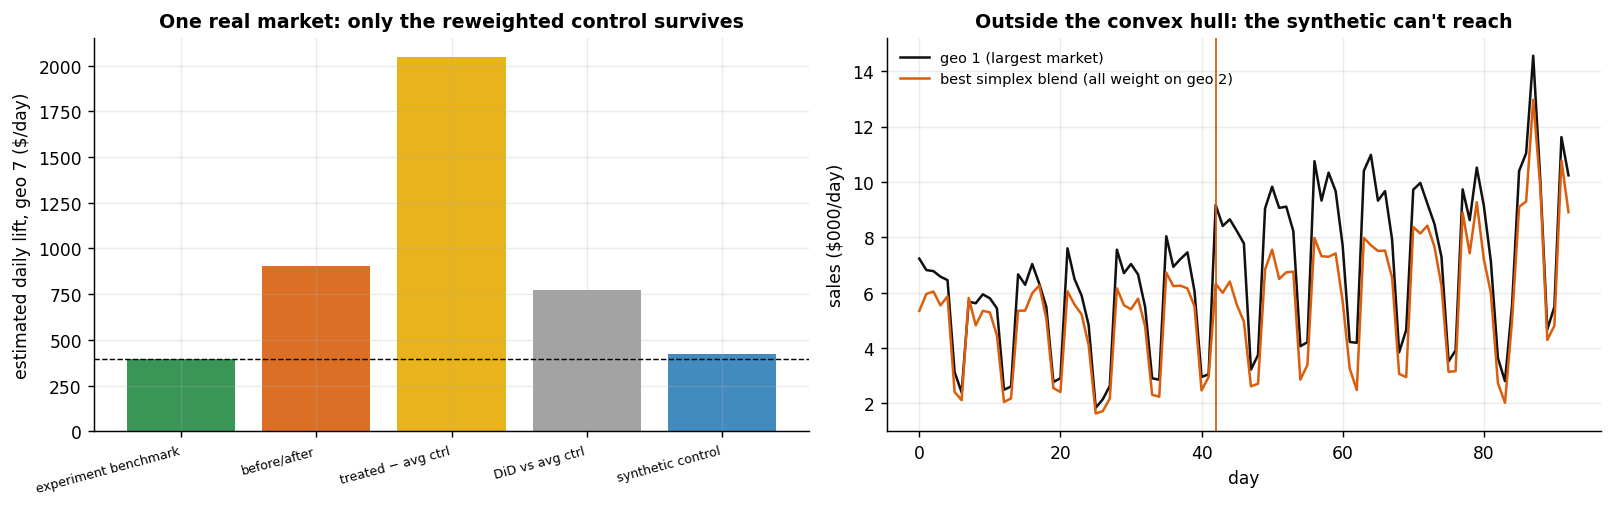

In [6]:
avg_ctrl = panel[control_geos].mean(axis=1).values
anchor_iroas = did_total / SPEND

# --- geo 7: the bake-off ---
g7 = 7
y7 = panel[g7].values
spend7 = float(cost[g7].sum()) / 1000.0                       # $000s of spend this geo received
bench7 = anchor_iroas * spend7 / n_days                        # $000/day, if per-$ effect is uniform
gap7, w7 = est.sc_effect_slsqp(y7, donors, pre, post)
ba7 = y7[post].mean() - y7[pre].mean()
tavg7 = (y7[post] - avg_ctrl[post]).mean()
did7 = ba7 - (avg_ctrl[post].mean() - avg_ctrl[pre].mean())
sc7 = gap7[post].mean()
pr7 = float(np.sqrt(np.mean(gap7[pre] ** 2)))
bake = {"experiment benchmark": bench7, "before/after": ba7,
        "treated − avg ctrl": tavg7, "DiD vs avg ctrl": did7, "synthetic control": sc7}

# --- geo 1: outside the convex hull ---
g1 = 1
y1 = panel[g1].values
gap1, w1 = est.sc_effect_slsqp(y1, donors, pre, post)
cf1 = w1 @ donors
pr1 = float(np.sqrt(np.mean(gap1[pre] ** 2)))
gate1_ref = abs(gap1[post].mean()) / 3
gate7_ref = abs(sc7) / 3

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
cols = [plots.GREEN, plots.ORANGE, plots.GOLD, plots.GREY, plots.BLUE]
ax[0].bar(list(bake.keys()), [v * 1000 for v in bake.values()], color=cols, alpha=0.9)
ax[0].axhline(bench7 * 1000, color="k", ls="--", lw=0.8)
ax[0].set_ylabel("estimated daily lift, geo 7 ($/day)")
ax[0].set_title("One real market: only the reweighted control survives")
plt.setp(ax[0].get_xticklabels(), rotation=15, ha="right", fontsize=7)
ax[1].plot(t, y1, color="#111", lw=1.4, label="geo 1 (largest market)")
ax[1].plot(t, cf1, color=plots.ORANGE, lw=1.4, label="best simplex blend (all weight on geo 2)")
ax[1].axvline(launch, color=plots.ORANGE, lw=1)
ax[1].set_xlabel("day"); ax[1].set_ylabel("sales ($000/day)")
ax[1].set_title("Outside the convex hull: the synthetic can't reach")
ax[1].legend(frameon=False, fontsize=8); fig.tight_layout()

print(json.dumps({k: round(v * 1000) for k, v in bake.items()}, indent=2))
print(f"geo 7 gate: pre-RMSE ${pr7 * 1000:.0f} vs |daily lift|/3 = ${gate7_ref * 1000:.0f} -> "
      f"{'PASS' if pr7 < gate7_ref else 'FAIL'}   (weights spread over ~{1 / np.sum(w7 ** 2):.0f} donors)")
print(f"geo 1 gate: pre-RMSE ${pr1 * 1000:.0f} vs |daily lift|/3 = ${gate1_ref * 1000:.0f} -> "
      f"{'PASS' if pr1 < gate1_ref else 'FAIL'}  (effective donors {1 / np.sum(w1 ** 2):.1f}: "
      f"all weight on geo {control_geos[int(np.argmax(w1))]}; implied iROAS "
      f"{gap1[post].sum() * 1000 / float(cost[g1].sum()):.1f} vs the experiment's {anchor_iroas:.2f} — inflated ~75%)")

**Read-out.** Against geo 7's ≈ +$394/day benchmark: **before/after lands at +$904**
(2.3× too big — it credits the campaign with spring), **treated − average control at +$2,049**
(5× — it books geo 7's size as lift), **DiD at +$771** (2× — level fixed, sensitivity still wrong:
a $1.8k/day market swings harder per common shock than the $0.6k/day average control), and
**synthetic control at +$423, within ~7%**, with the gate PASSing (pre-RMSE $122 vs the $141 bar).
Same data, four estimates, one survivor — 07's bake-off, no simulator required. And geo 1 is the
counterexample that keeps us honest: the country's largest market has no counterfactual among
smaller donors, the gate FAILs loudly (pre-RMSE $868 vs a $665 bar), and the estimate it would have
produced — iROAS ≈ 5.1 vs the experiment's 2.94 — is exactly the number an unscrupulous deck would
have shipped. **When the treated unit escapes the donor hull, aggregate or walk away.**

---
# Depth B · Placebo inference — is the gap statistically real?

Same inferential logic as 07, adapted to the design. The treated unit is a *cell* — the mean of
50 geos — so the fair placebo is not a single geo but a **pseudo-cell**: draw 25 of the 50
*control* geos at random (the largest cell that still leaves a donor pool), pretend they were a
campaign cell, fit them a synthetic control from the remaining 25, and record the post-window
"gap." None of these bundles saw a single ad dollar, so their gaps map out pure noise — **the
permutation distribution the design itself generates**. One scale mismatch to own: a mean of 25
geos is noisier than the real cell's mean of 50 (roughly 2× the idiosyncratic variance), and each
placebo fit gets only 25 donors instead of 50 — both push the placebo gaps *wider* than the real
cell's own null, so the permutation p is, if anything, **conservative**; a real cell that still
tops these noisier placebos has cleared a higher bar than the nominal p suggests. Two
test statistics, as in 07: the raw mean post-gap, and Abadie's scale-free **post/pre RMSE ratio**
(which doesn't reward bundles that simply fit badly everywhere). We also rerun 07's
**placebo-in-time** — a fake launch 14 days before the real one, inside the pre-period.

This permutation test is the *calibrated* significance statement for this notebook — the
posterior band is the optimistic one (07's multi-seed lesson), the rank among placebos is honest by
construction.

pseudo-cell permutation: real gap $+105/geo/day vs placebo 95% range [-17, +21]  ->  p = 0.010
RMSE-ratio test: real cell 16.1 vs placebo median 1.78  ->  p = 0.005 (no placebo bundle comes close: the real cell ranks 1st of all 201 units)
placebo-in-time: fake-launch gap $-8/geo/day — 7% of the real $+107 effect and the wrong sign (pre-fit RMSE $4) — no anticipation, no invented lift


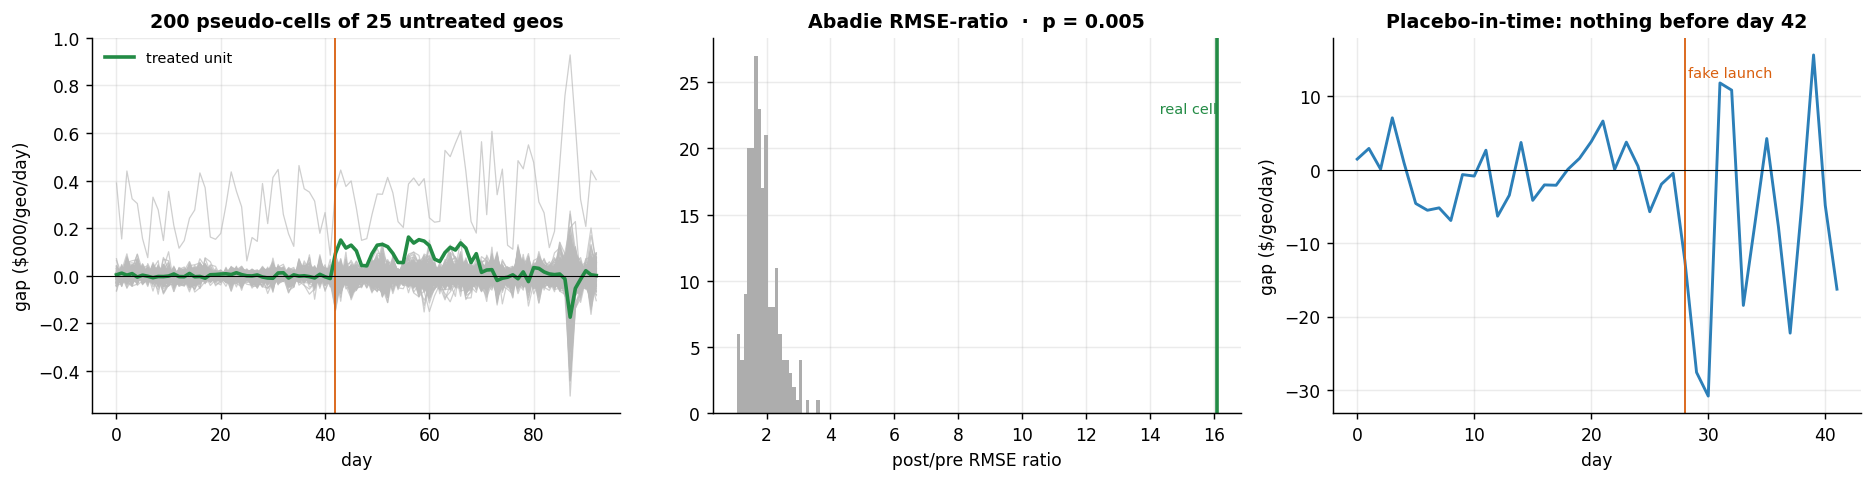

In [7]:
def rmse_ratio(gap):
    return float(np.sqrt(np.mean(gap[post] ** 2)) / max(np.sqrt(np.mean(gap[pre] ** 2)), 1e-9))

real_ratio = rmse_ratio(slsqp_gap)
real_gap_mean = slsqp_gap[post].mean()
rng = np.random.default_rng(7)
paths, ratios_p, gaps_p = [], [], []
for b in range(N_PSEUDO):
    half = rng.choice(len(control_geos), 25, replace=False)
    rest = np.setdiff1d(np.arange(len(control_geos)), half)
    y_p = panel[[control_geos[i] for i in half]].mean(axis=1).values
    gp, _ = est.sc_effect_slsqp(y_p, donors[rest], pre, post)
    paths.append(gp); ratios_p.append(rmse_ratio(gp)); gaps_p.append(gp[post].mean())
ratios_p, gaps_p = np.array(ratios_p), np.array(gaps_p)
p_gap = (np.sum(np.abs(gaps_p) >= abs(real_gap_mean)) + 1) / (N_PSEUDO + 1)
p_ratio = (np.sum(ratios_p >= real_ratio) + 1) / (N_PSEUDO + 1)

FAKE = launch - 14
gap_fake, _ = est.sc_effect_slsqp(y_tr[:launch], donors[:, :launch], slice(0, FAKE), slice(FAKE, launch))
fake_effect = float(gap_fake[FAKE:launch].mean())
fake_prermse = float(np.sqrt(np.mean(gap_fake[:FAKE] ** 2)))

fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.8))
plots.placebo_spaghetti(ax[0], t, paths, slsqp_gap, launch, p_gap, xlabel="day", ylabel="gap ($000/geo/day)")
ax[0].set_title(f"{N_PSEUDO} pseudo-cells of 25 untreated geos")
ax[1].hist(ratios_p, bins=24, color=plots.GREY, alpha=0.8)
ax[1].axvline(real_ratio, color=plots.GREEN, lw=2)
ax[1].text(real_ratio, ax[1].get_ylim()[1] * 0.8, " real cell", fontsize=8, color=plots.GREEN, ha="right")
ax[1].set_xlabel("post/pre RMSE ratio"); ax[1].set_title(f"Abadie RMSE-ratio  ·  p = {p_ratio:.3f}")
ax[2].plot(t[:launch], gap_fake * 1000, color=plots.BLUE, lw=1.6)
ax[2].axvline(FAKE, color=plots.ORANGE, lw=1); ax[2].axhline(0, color="k", lw=0.6)
ax[2].text(FAKE + 0.3, ax[2].get_ylim()[1] * 0.7, "fake launch", color=plots.ORANGE, fontsize=8)
ax[2].set_xlabel("day"); ax[2].set_ylabel("gap ($/geo/day)"); ax[2].set_title("Placebo-in-time: nothing before day 42")
fig.tight_layout()

print(f"pseudo-cell permutation: real gap ${real_gap_mean * 1000:+.0f}/geo/day vs placebo 95% range "
      f"[{np.quantile(gaps_p, .025) * 1000:+.0f}, {np.quantile(gaps_p, .975) * 1000:+.0f}]  ->  p = {p_gap:.3f}")
rank = int((ratios_p >= real_ratio).sum()) + 1
rank_msg = (f"no placebo bundle comes close: the real cell ranks 1st of all {N_PSEUDO + 1} units"
            if rank == 1 else f"{rank - 1} placebo bundle(s) beat the real cell: rank {rank} of {N_PSEUDO + 1} units")
print(f"RMSE-ratio test: real cell {real_ratio:.1f} vs placebo median {np.median(ratios_p):.2f}  ->  p = {p_ratio:.3f} "
      f"({rank_msg})")
print(f"placebo-in-time: fake-launch gap ${fake_effect * 1000:+.0f}/geo/day — {abs(fake_effect / post_gap):.0%} of "
      f"the real ${post_gap * 1000:+.0f} effect and the wrong sign (pre-fit RMSE ${fake_prermse * 1000:.0f}) — "
      f"no anticipation, no invented lift")

**Read-out.** The spaghetti plot says it before any statistic does: the real cell's post-launch
gap (≈ +$105/geo/day, printed above) sits far outside anything the untreated pseudo-cells produce,
and Abadie's scale-free RMSE ratio — the real cell near 16 against a placebo median near 2 —
removes the objection that it merely fits badly everywhere. Read the printed p-values carefully,
though. First, a permutation p has a *floor* of $1/(N_{\text{pseudo}}+1)$ — $1/201 \approx 0.005$
at the FULL run's 200 placebos — so hitting the floor means "the most extreme unit we observed,"
not an arbitrarily small tail probability; the print above reports the real cell's actual rank
rather than asserting it. Second, recall the scale mismatch flagged above: these 25-geo placebos
are *noisier* than the 50-geo real cell, so the printed p is conservative. The placebo-in-time
closes the loop: a fake launch 14 days inside the pre-period finds ≈ −$8/geo/day — under a tenth
of the real effect, and the wrong sign — no anticipation, no invented lift.

---
# Depth C · The dollar decision & sensitivity

Three stress tests on the number a CMO would repeat in a board meeting, then the verdict.
**Launch-date sweep**: as in 07, mis-dating the campaign folds no-effect days into the window and
dilutes the average — the estimate should peak *at* the true launch, and the peak is itself a
diagnostic that we dated it right. **Donor-pool halving**: refit on random halves of the donor
pool; a result that owns its donor pool shouldn't lurch. **The margin × iROAS surface** is already
in Step 6; here we print the summary a decision memo needs.

{
  "total_incremental_sales_k": 149.1,
  "ci90_k": [
    140.7,
    157.6
  ],
  "iroas": 2.98,
  "did_anchor_k": 147.2,
  "did_anchor_se_k": 41.9,
  "pre_rmse_gate": "PASS",
  "p_pseudo_gap": 0.01,
  "p_rmse_ratio": 0.005,
  "placebo_in_time_gap": -7.8,
  "cooldown_gap_per_day": -2.5,
  "break_even_margin": 0.335,
  "P_profitable_at_35pct_margin": 0.889,
  "decision_at_35pct": "TEST FURTHER"
}


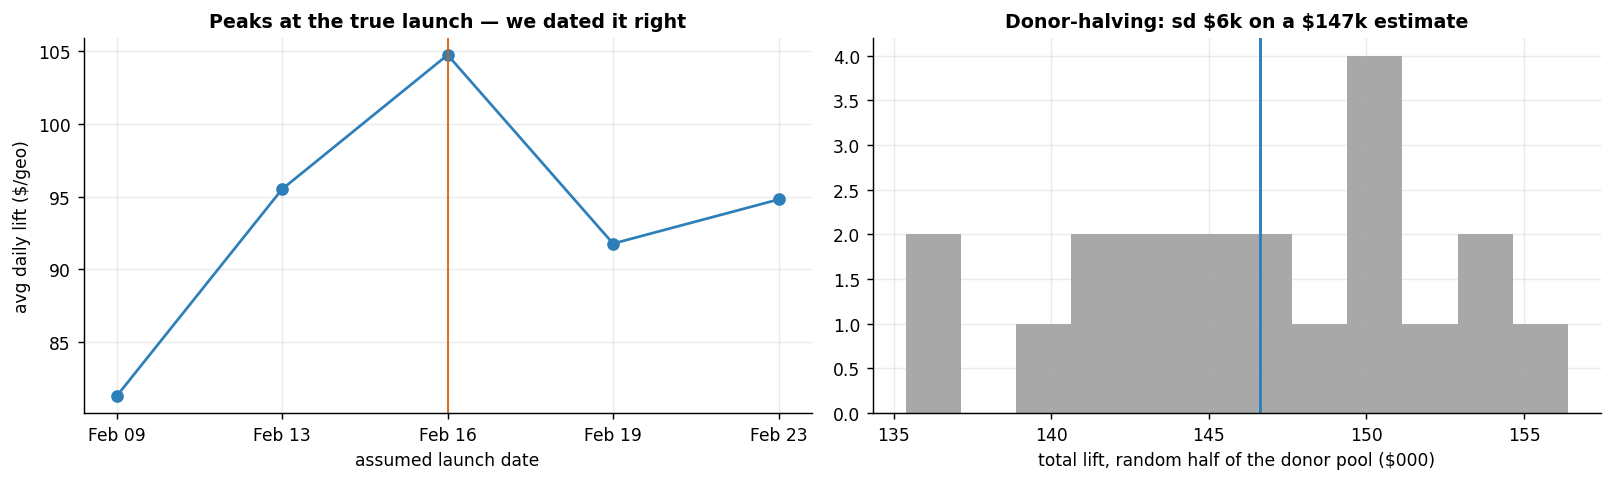

In [8]:
launch_grid = [launch - 7, launch - 3, launch, launch + 3, launch + 7]
lifts = []
for L in launch_grid:
    gp, _ = est.sc_effect_slsqp(y_tr, donors, slice(0, L), slice(L, end_post))
    lifts.append(gp[L:end_post].mean() * 1000)
halves = []
rng2 = np.random.default_rng(3)
for b in range(10 if FAST else 20):
    half = rng2.choice(len(control_geos), 25, replace=False)
    gp, _ = est.sc_effect_slsqp(y_tr, donors[half], pre, post)
    halves.append(gp[post].sum() * n_treat)
halves = np.array(halves)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].plot([dates[L].strftime("%b %d") for L in launch_grid], lifts, color=plots.BLUE, marker="o")
ax[0].axvline(2, color=plots.ORANGE, lw=1)
ax[0].set_xlabel("assumed launch date"); ax[0].set_ylabel("avg daily lift ($/geo)")
ax[0].set_title("Peaks at the true launch — we dated it right")
ax[1].hist(halves, bins=12, color=plots.GREY, alpha=0.85)
ax[1].axvline(slsqp_total, color=plots.BLUE, lw=1.6)
ax[1].set_xlabel("total lift, random half of the donor pool ($000)")
ax[1].set_title(rf"Donor-halving: sd \${halves.std():.0f}k on a \${slsqp_total:.0f}k estimate")
fig.tight_layout()

result = {"total_incremental_sales_k": round(float(total_post.mean()), 1),
          "ci90_k": [round(float(np.quantile(total_post, .05)), 1), round(float(np.quantile(total_post, .95)), 1)],
          "iroas": round(float(iroas.mean()), 2),
          "did_anchor_k": round(float(did_total), 1), "did_anchor_se_k": round(float(did_se), 1),
          "pre_rmse_gate": gate, "p_pseudo_gap": round(float(p_gap), 3), "p_rmse_ratio": round(float(p_ratio), 3),
          "placebo_in_time_gap": round(float(fake_effect * 1000), 1),
          "cooldown_gap_per_day": round(float(cool_gap * 1000), 1),
          "break_even_margin": round(float(m_be), 3),
          "P_profitable_at_35pct_margin": round(float(decision["P_value_gt_cost"]), 3),
          "decision_at_35pct": decision["decision"]}
print(json.dumps(result, indent=2))

### The one-paragraph decision

> The campaign **worked, and we can prove it to experimental standard**: the synthetic control
> tracks the treated cell to within ~$10/geo/day before launch (gate PASS), lands on the randomized
> matched-pairs answer ($149k vs $147k of incremental sales; iROAS 2.98 vs 2.94), is the most
> extreme unit on both placebo permutation tests (p ≈ 0.005–0.010), shows nothing material at a fake launch
> date (−$8/geo/day, 7% of the real effect, wrong sign), survives leave-one-out and donor-halving, and — the real-data bonus no simulator provides —
> **switches off within days of the spend stopping**, which both certifies the attribution and
> denies any carryover annuity. What the data *cannot* settle is profitability: $2.98 of revenue
> per ad dollar clears cost only above a **33.5% gross margin**, and reaches 90% confidence only
> above ~35.5%. So the briefing is two sentences, not one: *the lift is real and precisely measured;
> whether to scale is a margin question* — GO for the high-margin lines, NO-GO below one-in-three
> margins, and any national rollout should expect the marginal iROAS to sag below this test's 2.98
> (saturation, notebook 06) — so re-test at scale rather than extrapolate.